In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


print("done")

done


In [8]:
dataset = pd.read_csv("Ai-data.csv")
dataset.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label
0,01-01-2024 00:00,0.457786,0.469524,0.396368,0.445441,0.692057,Normal
1,01-01-2024 00:30,0.351956,0.465545,0.451184,0.458729,0.539874,Normal
2,01-01-2024 01:00,0.482948,0.285415,0.408289,0.470360,0.614724,Normal
3,01-01-2024 01:30,0.628838,0.482095,0.512308,0.576241,0.757044,Normal
4,01-01-2024 02:00,0.335974,0.624741,0.672021,0.373004,0.673981,Normal


In [10]:
# Converting Normal -> 0 and Abnormal -> 1 
dataset["Anomaly_Label"] = dataset["Anomaly_Label"].map({"Normal": 0, "Abnormal": 1})
print(dataset["Anomaly_Label"].value_counts())


Anomaly_Label
0    4750
1     250
Name: count, dtype: int64


In [11]:
# Splitting the data
x = dataset.drop(columns=["Timestamp", "Anomaly_Label"])
y=dataset["Anomaly_Label"]

In [12]:
# OverSampling
from imblearn.over_sampling import RandomOverSampler

In [13]:
ro = RandomOverSampler()
ro_x, ro_y = ro.fit_resample(x,y)

In [14]:
ro_y.value_counts()

Anomaly_Label
0    4750
1    4750
Name: count, dtype: int64

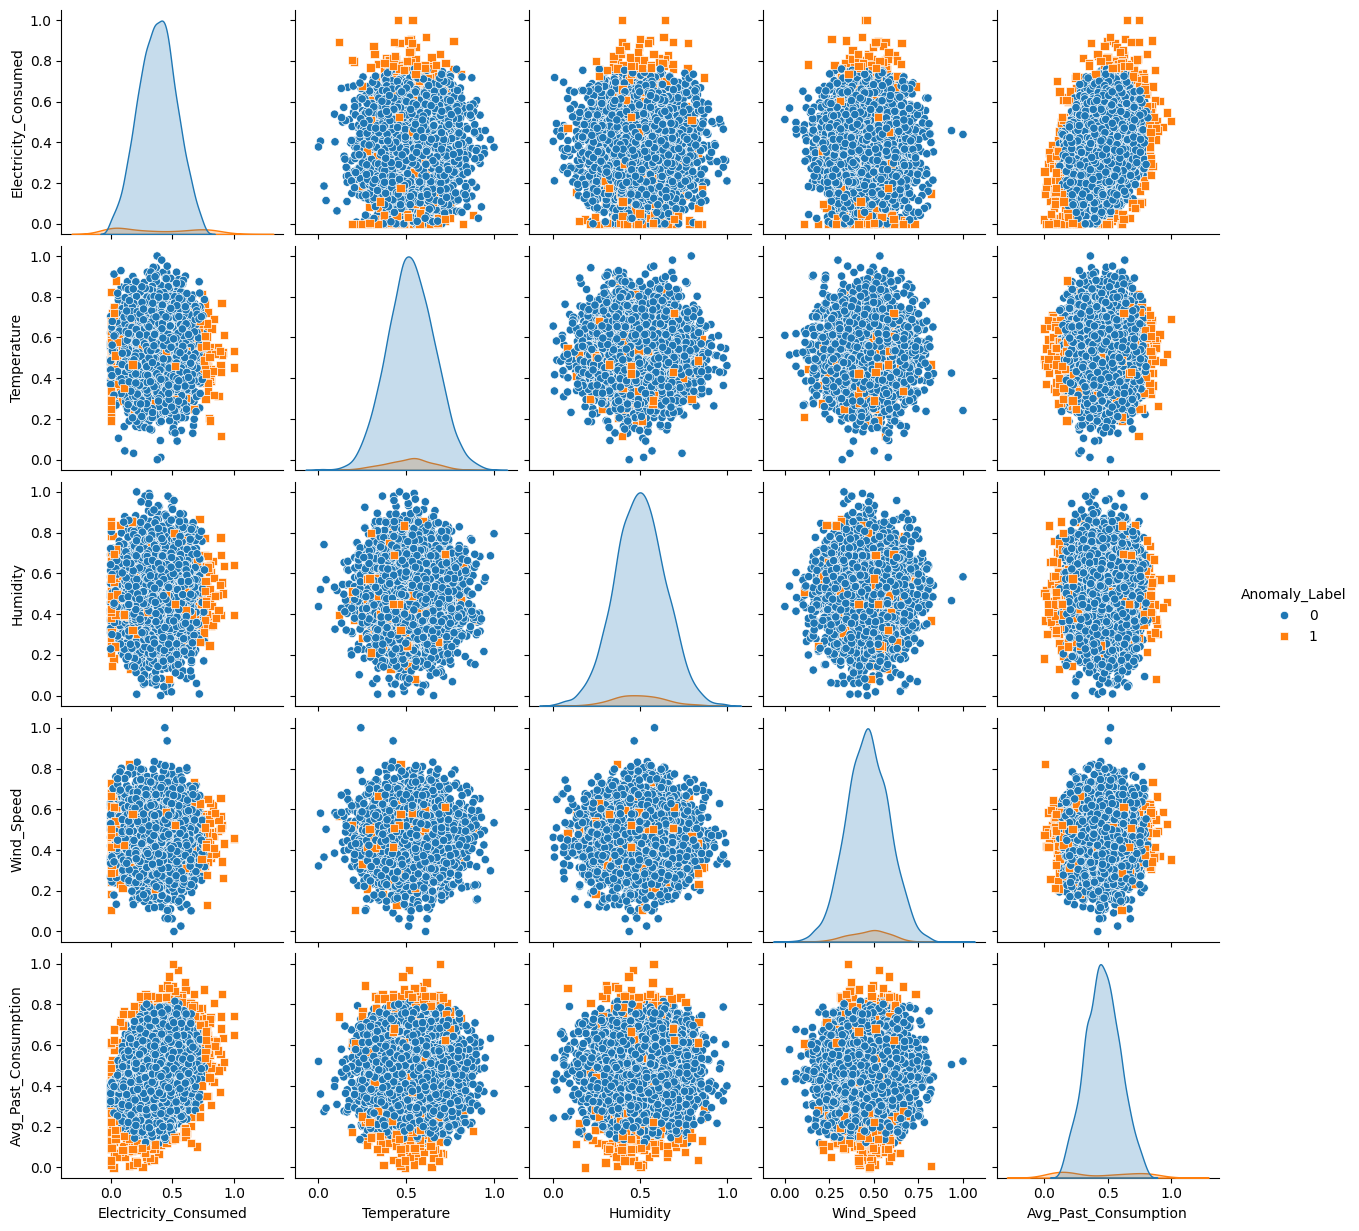

In [15]:
sns.pairplot(dataset, hue='Anomaly_Label', diag_kind='kde', markers=["o", "s"])
plt.show()

# Polynomial Logistic Regression 

In [16]:
# Polynomial Conversion

In [17]:
from sklearn.preprocessing import PolynomialFeatures

In [18]:
pf = PolynomialFeatures(degree=2)
pf.fit(ro_x)
x = pd.DataFrame(pf.transform(ro_x))

In [ ]:
# Splitting Data

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train, x_test, y_train, y_test = train_test_split(ro_x, ro_y, test_size=0.2, random_state=42)

In [ ]:
# Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

In [14]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
lr.score(x_test,y_test)*100

55.315789473684205

In [4]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [5]:
cf_1 = confusion_matrix(y_test, lr.predict(x_test))
precision1 = precision_score(y_test, lr.predict(x_test))
recall1 = recall_score(y_test, lr.predict(x_test))
f11 = f1_score(y_test, lr.predict(x_test))
print(f"Precision : {precision1:.4f}")
print(f"Recall    : {recall1:.4f}")
print(f"F1 Score  : {f11:.4f}")
print("Confusion Matrix:\n", cf_1)

NameError: name 'y_test' is not defined

In [ ]:
sns.heatmap(cf_1,annot = True, fmt='d', cmap='Purples', xticklabels=['0','1'], yticklabels=['0','1'])
plt.title('Confusion Matrix Heatmap')
plt.show()

# Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
rf.score(x_test, y_test) * 100

99.89473684210526

In [21]:
rf.predict([[0.351956, 0.465545, 0.451184, 0.458729, 0.539874]])


C:\Users\atharv\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

In [22]:
cf_2 = confusion_matrix(y_test, rf.predict(x_test))
precision2 = precision_score(y_test, rf.predict(x_test))
recall2 = recall_score(y_test, rf.predict(x_test))
f12 = f1_score(y_test, rf.predict(x_test))
print(f"Precision : {precision2:.4f}")
print(f"Recall    : {recall2:.4f}")
print(f"F1 Score  : {f12:.4f}")
print("Confusion Matrix:\n", cf_2)

Precision : 0.9979
Recall    : 1.0000
F1 Score  : 0.9989
Confusion Matrix:
 [[965   2]
 [  0 933]]


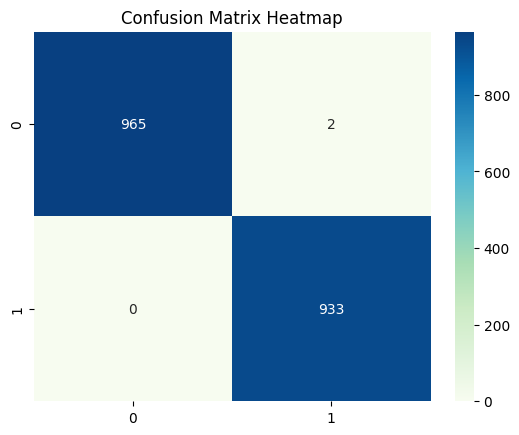

In [21]:
sns.heatmap(cf_2,annot = True, fmt='d', cmap='GnBu', xticklabels=['0','1'], yticklabels=['0','1'])
plt.title('Confusion Matrix Heatmap')
plt.show()

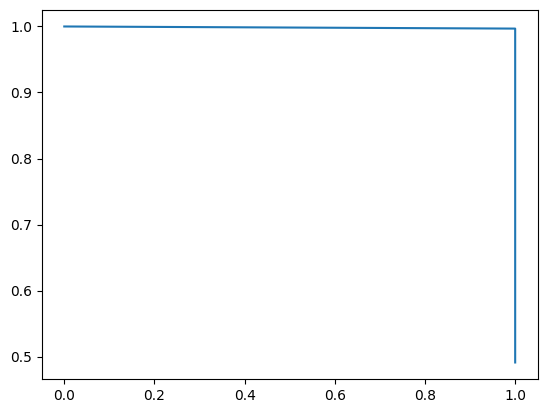

In [41]:
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, rf.predict(x_test))
plt.plot(recall, precision)
plt.show()

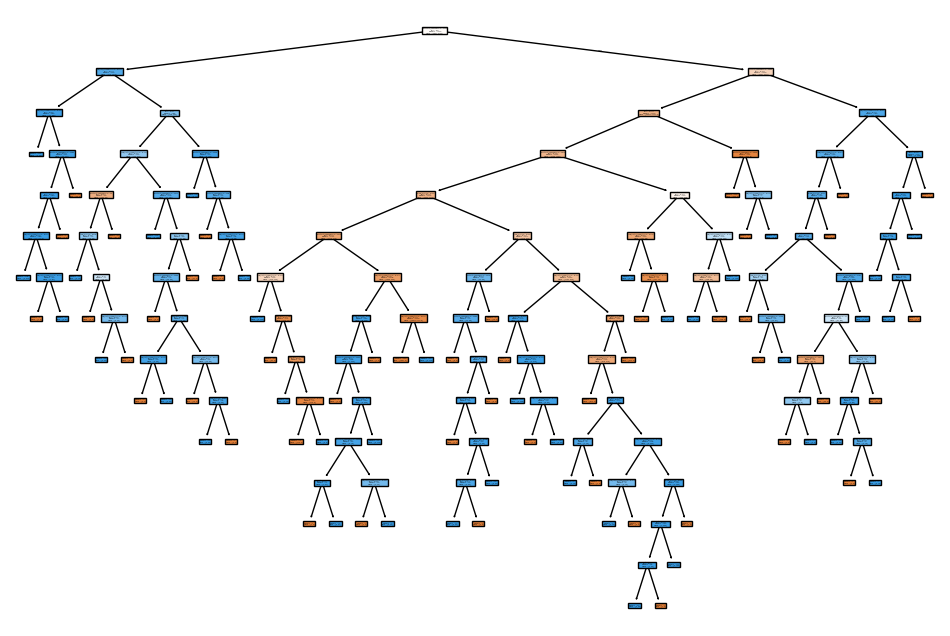

In [38]:
from sklearn.tree import plot_tree
feature_names = ['Electricity_Consumed',	'Temperature',	'Humidity',	'Wind_Speed',	'Avg_Past_Consumption']
plt.figure(figsize=(12,8))
plot_tree(rf.estimators_[0], feature_names=feature_names, filled=True)
plt.show()

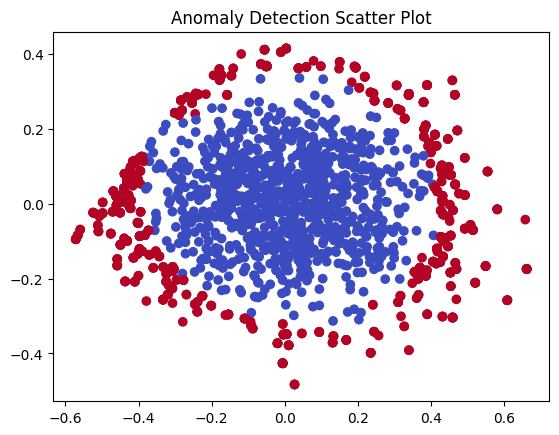

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_test)

plt.scatter(X_pca[:,0], X_pca[:,1], c=rf.predict(x_test), cmap='coolwarm')
plt.title("Anomaly Detection Scatter Plot")
plt.show()

In [23]:
import gradio as gr

def predict(f1, f2, f3, f4, f5):
    feature_names = x_train.columns  # keep the same column names
    new_data = pd.DataFrame([[f1,f2,f3,f4,f5]], columns=feature_names)
    pred = rf.predict(new_data)[0]
    return f"Predicted Class: {pred}"

# Build Gradio GUI
inputs = [
    gr.Number(label="Electricity_Consumed"),
    gr.Number(label="Temperature"),
    gr.Number(label="Humidity"),
    gr.Number(label="Wind_Speed"),
    gr.Number(label="Avg_Past_Consumption")
]

output = gr.Textbox(label="Prediction")

app = gr.Interface(fn=predict, inputs=inputs, outputs=output, title="Random Forest Classifier")

# Launch the app
app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [45]:
app.close()


Closing server running on port: 7862
